#Asigment Customer Lifetime Value

#Import Library

In [1]:
# ============================================
# INSTALL LIBRARY
# ============================================

!pip install lifetimes
!pip install yellowbrick

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 7.6 MB/s eta 0:00:00


#Upload Dataset

In [2]:
# ============================================
# UPLOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()



Saving marketing_campaign.csv to marketing_campaign.csv


#Read Dataset

In [3]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv(
    'marketing_campaign.csv',
    sep='\t'
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


#Data Uderstanding

In [5]:
print(df.shape)

(2240, 29)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [8]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


#Data Preprocessing

##Missing Value

In [9]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [10]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


##Convert Date

In [11]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

##Education Grouping

In [13]:
df['Education'] = df['Education'].replace({
    'PhD':'PostGraduation',
    'Master':'PostGraduation',
    '2n Cycle':'UnderGraduation',
    'Basic':'UnderGraduation'
})
print(df['Education'].value_counts())

Education
Graduation         1127
PostGraduation      856
UnderGraduation     257
Name: count, dtype: int64


##Marital Grouping

In [15]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married':'Together',
    'Single':'Alone',
    'Divorced':'Alone',
    'Widow':'Alone',
    'YOLO':'Alone',
    'Absurd':'Alone'
})
print(df['Marital_Status'].value_counts())

Marital_Status
Together    1444
Alone        796
Name: count, dtype: int64


##Remove Outlier

In [17]:
df = df[df['Income'] < 600000]
df = df[df['NumDealsPurchases'] < 6]

print(df.shape)

(2092, 29)


##New Features

In [18]:
df['Age'] = 2026 - df['Year_Birth']

df['TotalChildren'] = (
    df['Kidhome']
    + df['Teenhome']
)

df['TotalSpend'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

df['TotalPurchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)


print(df[['Age', 'TotalChildren', 'TotalSpend', 'TotalPurchases']].head())

   Age  TotalChildren  TotalSpend  TotalPurchases
0   69              0        1617              22
1   72              2          27               4
2   61              0         776              20
3   42              1          53               6
4   45              1         422              14


#EDA

##Visual 1 Income Distribution

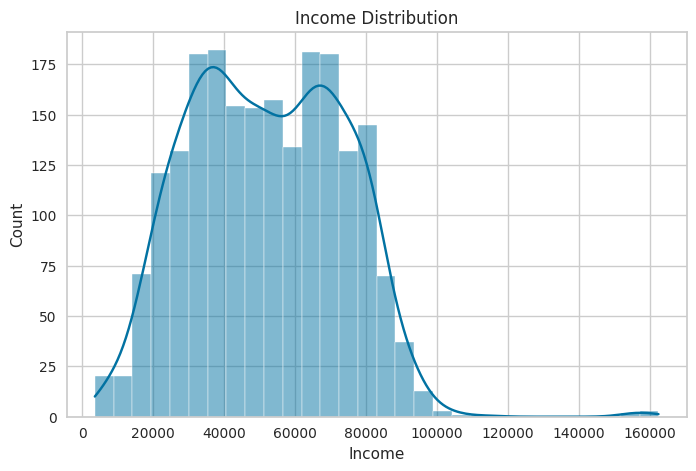

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.show()

Insight :



*   Grafik ini menunjukkan ada dua kelompok data yang paling dominan. Puncak pertama berada di sekitar pendapatan 35.000–40.000, dan puncak kedua berada di sekitar 65.000–70.000.
*   Sebagian besar data menumpuk di rentang pendapatan antara 20.000 hingga 85.000. Di luar rentang itu (sangat rendah atau sangat tinggi), jumlahnya langsung turun drastis.
*   Terlihat ada garis biru kecil yang memanjang di ujung kanan, mendekati angka 160.000. Ini menandakan ada segelintir orang yang pendapatannya jauh lebih tinggi dibanding mayoritas kelompok lainnya




##Visual 2 Education

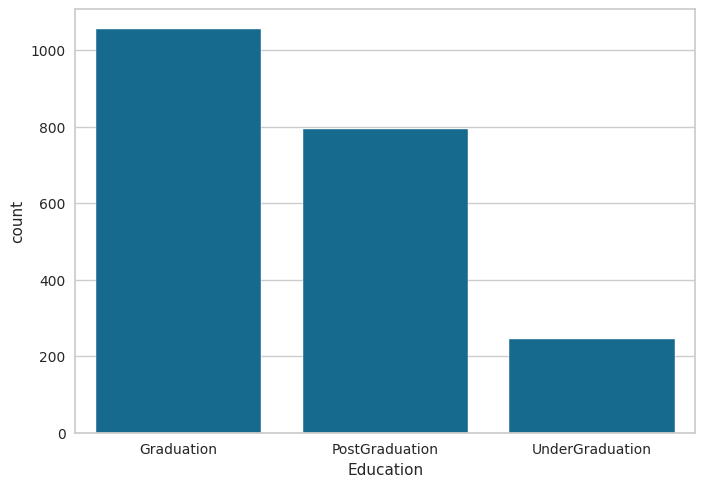

In [20]:
sns.countplot(
    data=df,
    x='Education'
)
plt.show()

Insight:


*    Grafik ini menunjukkan kalau mayoritas data diisi oleh kelompok **Graduation**, dengan jumlah paling tinggi menembus angka di atas 1000 orang
*   Kelompok **PostGraduation** berada di posisi kedua dengan jumlah yang juga cukup besar, yaitu mencapai kisaran 800 orang
*   Kelompok **UnderGraduation** menjadi yang paling sedikit di antara ketiganya, dengan jumlah yang cukup rendah di kisaran 250 orang saja



##Visual 3 Marital Status

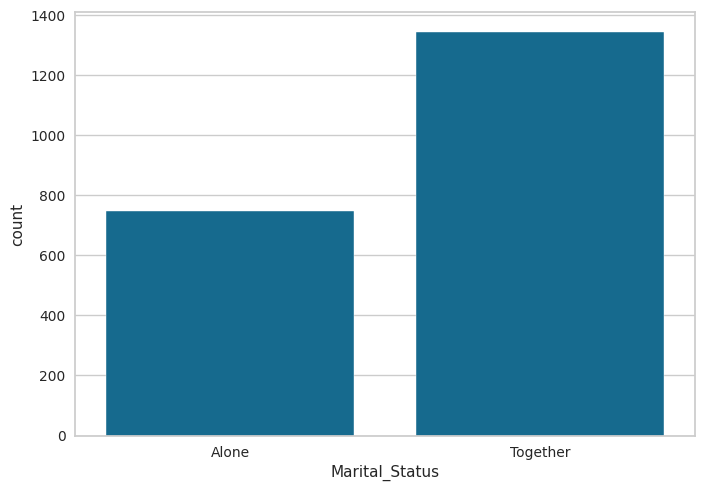

In [21]:
sns.countplot(
    data=df,
    x='Marital_Status'
)
plt.show()

Insight:


*   Grafik ini menunjukkan kalau jumlah orang dengan status Together jauh lebih mendominasi, dengan angka mencapai kisaran 1.350 orang
*   Kelompok dengan status Alone jumlahnya lebih sedikit, berada di kisaran 750 orang
*   Secara keseluruhan, perbandingan antara kelompok yang hidup berpasangan (Together) hampir dua kali lipat lebih banyak dibandingkan mereka yang hidup sendiri (Alone)



##Visual 4 Total Spend By Education

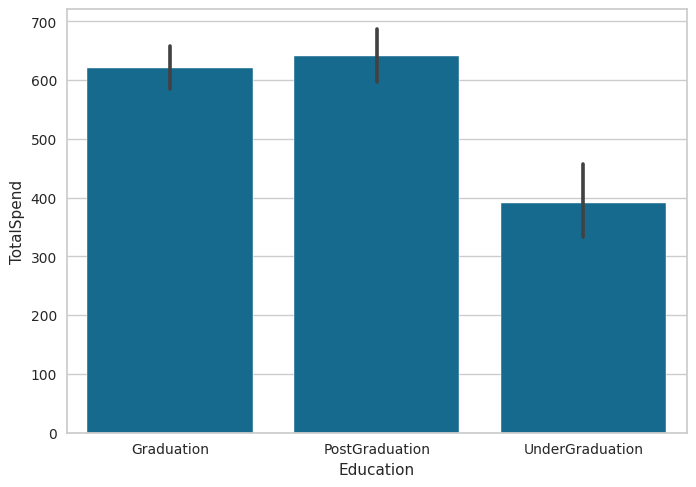

In [22]:
sns.barplot(
    data=df,
    x='Education',
    y='TotalSpend'
)
plt.show()

Insight:


*   Grafik ini menunjukkan kalau rata-rata pengeluaran tertinggi ada di kelompok kedua (kemungkinan besar PostGraduation/Graduation jika merujuk tren sebelumnya), dengan total pengeluaran mencapai kisaran 640
*   Kelompok pertama memiliki rata-rata pengeluaran yang tidak berbeda jauh, yaitu berada di kisaran 620
*   Kelompok ketiga (UnderGraduation) memiliki rata-rata pengeluaran yang paling rendah dibandingkan kelompok lainnya, yaitu hanya berada di kisaran 390



##Visual 5 Total Spend By Marital

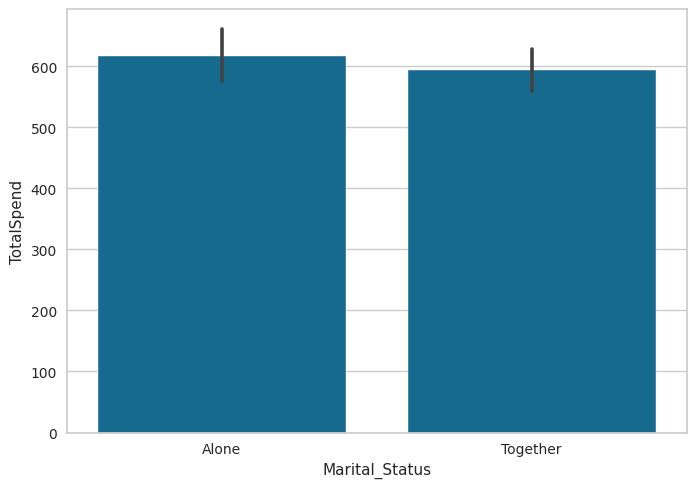

In [23]:
sns.barplot(
    data=df,
    x='Marital_Status',
    y='TotalSpend'
)
plt.show()

Insight:


*   Grafik ini menunjukkan kalau rata-rata pengeluaran antara kelompok Alone dan kelompok Together cenderung seimbang atau mirip
*   Kelompok Alone memiliki rata-rata pengeluaran sedikit lebih tinggi, berada di kisaran angka 620
*   Kelompok Together berada sedikit di bawahnya, dengan rata-rata pengeluaran di kisaran angka 590



##Visual 6 Produk Category

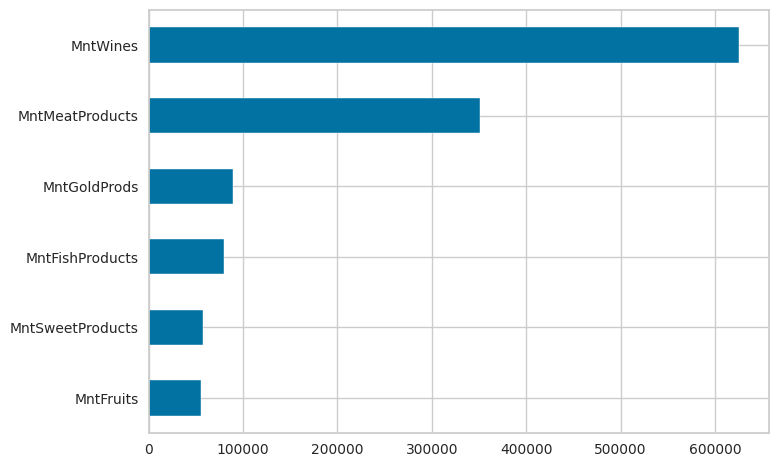

In [24]:
product = df[
[
'MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds'
]
].sum()

product.sort_values().plot(
    kind='barh'
)

plt.show()

Insight:


* Grafik ini menunjukkan kalau MntWines menjadi produk yang paling banyak dibeli atau memiliki total pengeluaran tertinggi, dengan angka mendominasi jauh di atas kisaran 600.000
* Produk daging (MntMeatProducts) menyusul di posisi kedua dengan jumlah pengeluaran yang juga cukup besar, yaitu berada di kisaran 350.000
* Kategori produk lainnya seperti emas, ikan, permen, dan buah (MntGoldProds hingga MntFruits) memiliki jumlah pengeluaran yang jauh lebih kecil dan cenderung mirip, semuanya berada di bawah kisaran 100.000



##Visual 7 Purchase Channel

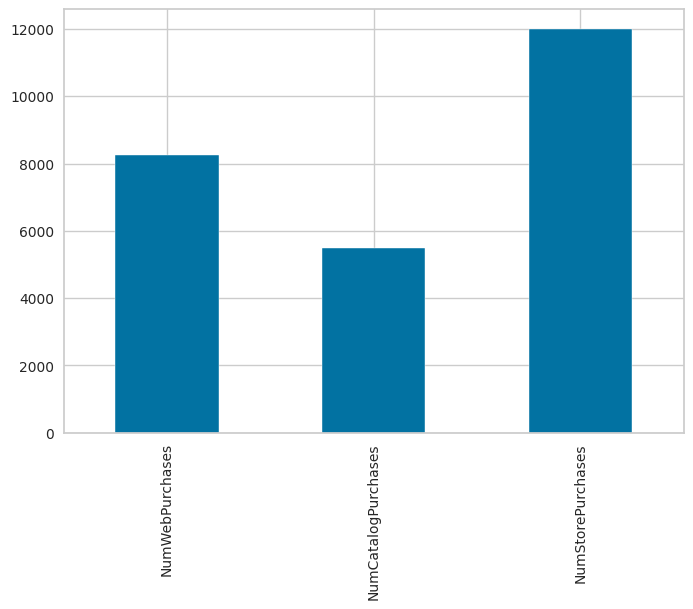

In [25]:
channel = df[
[
'NumWebPurchases',
'NumCatalogPurchases',
'NumStorePurchases'
]
].sum()

channel.plot(kind='bar')
plt.show()

Insight:



* Grafik ini menunjukkan kalau pembelian langsung di toko (NumStorePurchases) menjadi jalur belanja yang paling favorit, dengan jumlah paling tinggi mencapai angka 12.000
*   Pembelian lewat website (NumWebPurchases) berada di posisi kedua dengan performa yang cukup kuat, mencatat angka di kisaran 8.200
*   Pembelian melalui katalog (NumCatalogPurchases) menjadi metode yang paling jarang digunakan dibandingkan keduanya, dengan jumlah paling rendah di kisaran 5.500



##Visual 8 Income VS Spending

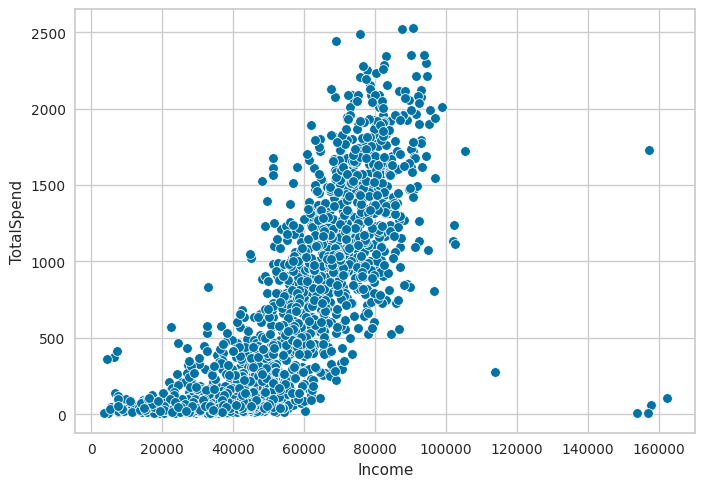

In [26]:
sns.scatterplot(
    data=df,
    x='Income',
    y='TotalSpend'
)
plt.show()

Insight:
* Grafik ini menunjukkan adanya hubungan positif yang kuat antara Income dan TotalSpend; semakin tinggi pendapatan seseorang, cenderung semakin besar pula total pengeluaran mereka
* Data menumpuk sangat padat di rentang pendapatan 40.000 hingga 100.000, di mana total pengeluaran melonjak signifikan dari kisaran 500 hingga menembus 2.500
* Terlihat beberapa titik pencilan (outliers) di ujung kanan bawah dengan pendapatan sangat tinggi di atas 150.000, namun total pengeluaran mereka justru sangat rendah atau mendekati 0



##Visual 9 Age VS Spending

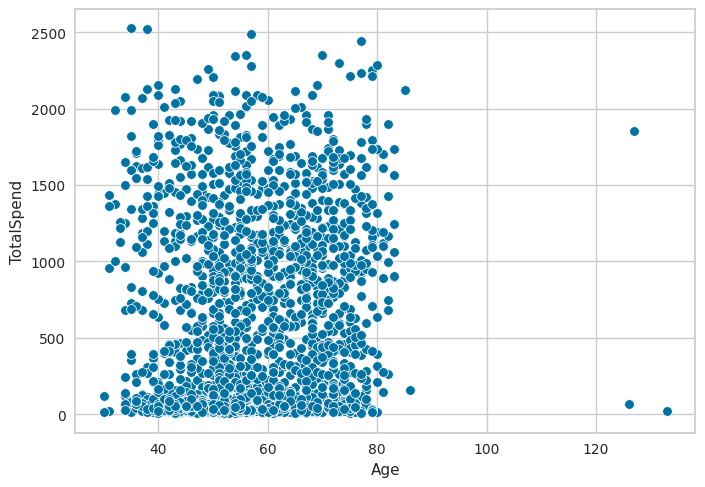

In [27]:
sns.scatterplot(
    data=df,
    x='Age',
    y='TotalSpend'
)
plt.show()

Insight:


* Grafik ini menunjukkan tidak adanya hubungan atau pola yang jelas antara Age dan TotalSpend; persebaran data terlihat acak dan tersebar merata di berbagai kelompok usia
* Data menumpuk sangat padat pada rentang usia produktif hingga lansia, yaitu sekitar 35 hingga 80 tahun, dengan total pengeluaran yang sangat bervariasi dari yang terendah mendekati 0 hingga menembus 2.500
* Terlihat ada beberapa titik pencilan (outliers) ekstrem di sisi kanan grafik, di mana terdapat individu dengan usia di atas 120 tahun tetapi memiliki total pengeluaran yang cenderung sangat rendah



##Visual 10 Campaign Acceptance

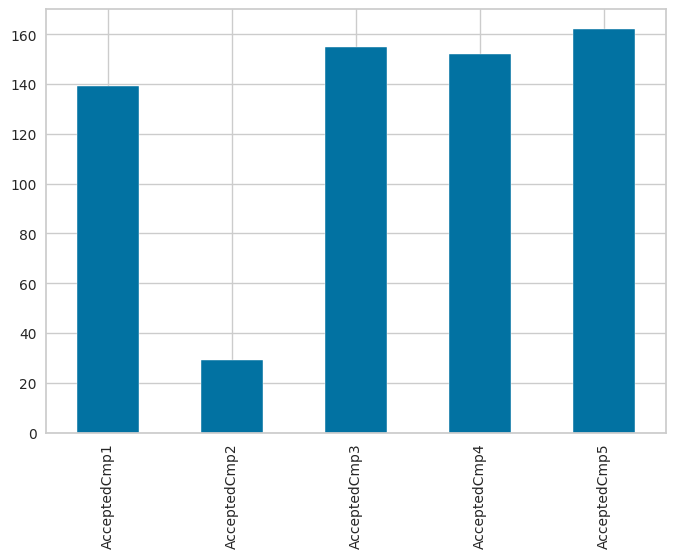

In [28]:
campaign = df[
[
'AcceptedCmp1',
'AcceptedCmp2',
'AcceptedCmp3',
'AcceptedCmp4',
'AcceptedCmp5'
]
].sum()

campaign.plot(kind='bar')
plt.show()

Insight:


* Grafik ini menunjukkan kalau kampanye kelima (AcceptedCmp5) mendapatkan respons tertinggi atau paling banyak diterima, dengan jumlah mencapai angka di kisaran 162
* Kampanye kedua (AcceptedCmp2) menjadi performa yang paling jeblok atau paling sedikit diterima dibandingkan yang lain, dengan jumlah sangat rendah di kisaran angka 30
* Tiga kampanye lainnya (AcceptedCmp1, AcceptedCmp3, dan AcceptedCmp4) memiliki performa yang relatif bersaing ketat dan cukup sukses, semuanya berada di rentang angka 140 hingga 155


#RFM Analysis

##Create RFM Table

In [29]:
rfm = df[['ID','Recency']].copy()

rfm['Frequency'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

rfm['Monetary'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

##Scoring

In [30]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

##Total Score

In [31]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

##Segment

In [32]:
rfm['RFM_Total'] = (
    rfm['R_Score'].astype(int)
    + rfm['F_Score'].astype(int)
    + rfm['M_Score'].astype(int)
)

def segment(score):

    if score >= 13:
        return 'Champion'

    elif score >= 10:
        return 'Loyal Customer'

    elif score >= 7:
        return 'Potential Loyalist'

    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Total'].apply(segment)

##RFM Visualization

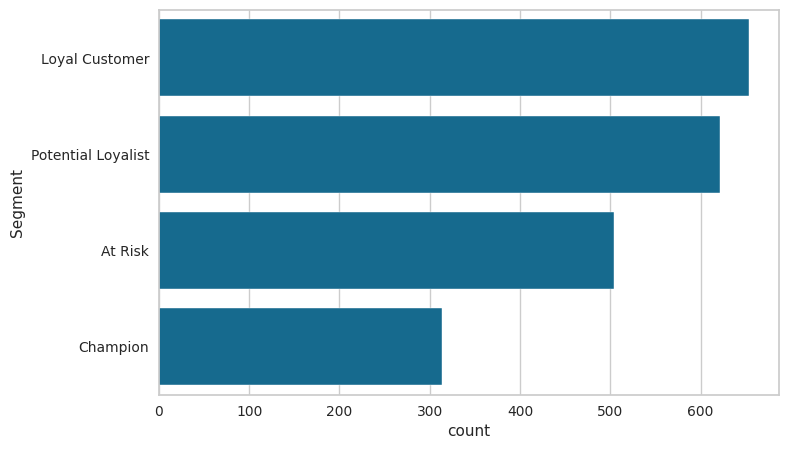

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    y='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.show()

Insight:
* Grafik ini menunjukkan kalau kategori Loyal Customer menjadi segmen pelanggan yang paling mendominasi dengan jumlah tertinggi mencapai kisaran 650 orang
* Kelompok Potential Loyalist menempel ketat di posisi kedua dengan jumlah yang tidak kalah besar, yaitu berada di kisaran 620 orang
* Segmen Champion memiliki jumlah yang paling sedikit dibandingkan segmen lainnya, yaitu hanya berada di kisaran 310 orang, atau sekitar setengah dari total pelanggan setia



#CLV Analysis

##CLV Calculation

In [35]:
rfm['CLV'] = (
    rfm['Monetary']
    * rfm['Frequency']
)

##CLV Segment

In [36]:
rfm['CLV_Segment'] = pd.qcut(
    rfm['CLV'],
    4,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'VIP'
    ]
)

##Visual CLV

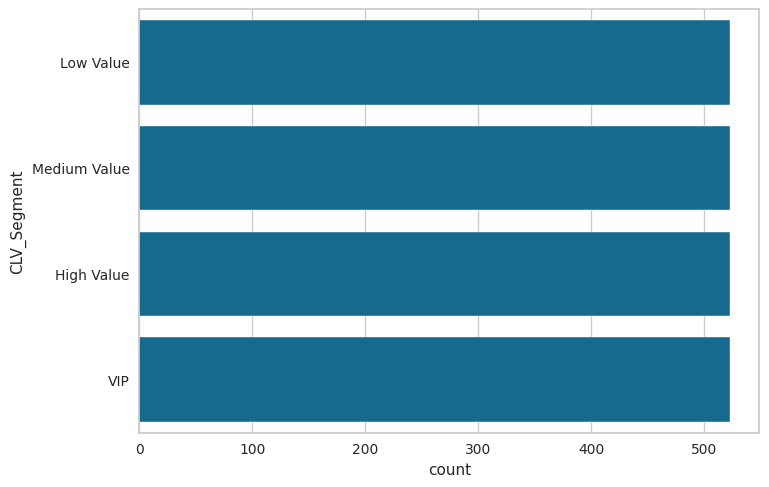

In [37]:
sns.countplot(
    data=rfm,
    y='CLV_Segment'
)

plt.show()

In [52]:
# ============================================
# PRODUCT PERFORMANCE TABLE
# ============================================

# Convert the Series to a DataFrame and reset the index
product = product.reset_index()

# Rename the columns to make them more descriptive
product.columns = ['Product_Category', 'Amount']

# Replace the product category names for better readability
product['Product_Category'] = (
    product['Product_Category']
    .replace({
        'MntWines':'Wine',
        'MntFruits':'Fruit',
        'MntMeatProducts':'Meat',
        'MntFishProducts':'Fish',
        'MntSweetProducts':'Sweet',
        'MntGoldProds':'Gold'
    })
)

product.head()

,Product_Category,Amount
0,Wine,625617
1,Fruit,55942
2,Meat,351012
3,Fish,79549
4,Sweet,57384


#Export Final Dataset

In [53]:
import os

final_df = df.merge(
    rfm,
    on='ID',
    how='left'
)

# Langsung ke My Drive
output_path = "/content/drive/MyDrive/Assigment/Assigment Extra Class 9/customer_clv_dashboard.csv"

final_df.to_csv(output_path, index=False)

print("Berhasil disimpan di:", output_path)

Berhasil disimpan di: /content/drive/MyDrive/Assigment/Assigment Extra Class 9/customer_clv_dashboard.csv


In [55]:
final_df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency_x',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response',
 'Age',
 'TotalChildren',
 'TotalSpend',
 'TotalPurchases',
 'Recency_y',
 'Frequency',
 'Monetary',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'RFM_Total',
 'Segment',
 'CLV',
 'CLV_Segment']